In [1]:
import os
import torch
import torchaudio
import matplotlib.pyplot as plt
import pandas as pd
import pyroomacoustics as pra

___
# Analyze Database

In [2]:
ROOT_TRN = '/home/ovistetom/Documents/Databases_Local/MIXTURES/reference/tst'
SAMPLE_RATE = 16000
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
info = {}

for i, name_sample in enumerate(os.listdir(ROOT_TRN)):
    path_sample = os.path.join(ROOT_TRN, name_sample)

    noisy_mixture = torchaudio.load(os.path.join(path_sample, 'noisy_mixture.flac'), normalize=True, channels_first=True)[0]
    overall_noise = torchaudio.load(os.path.join(path_sample, 'overall_noise.flac'), normalize=True, channels_first=True)[0]
    ambient_noise = torchaudio.load(os.path.join(path_sample, 'ambient_noise.flac'), normalize=True, channels_first=True)[0]
    target_speech = torchaudio.load(os.path.join(path_sample, 'target_speech.flac'), normalize=True, channels_first=True)[0]
    reverb_speech = torchaudio.load(os.path.join(path_sample, 'reverb_speech.flac'), normalize=True, channels_first=True)[0]
    interf_speech = torchaudio.load(os.path.join(path_sample, 'interf_speech.flac'), normalize=True, channels_first=True)[0]

    target_speech = target_speech + reverb_speech

    length = noisy_mixture.size(1)
    sir = target_speech.pow(2.0).sum() / interf_speech.pow(2.0).sum()
    sir = 10*torch.log10(sir).item()
    snr = target_speech.pow(2.0).sum() / ambient_noise.pow(2.0).sum()
    snr = 10*torch.log10(snr).item()
    sor = target_speech.pow(2.0).sum() / overall_noise.pow(2.0).sum()
    sor = 10*torch.log10(sor).item()

    info[i] = [name_sample, length/16000, sir, snr, sor]

In [5]:
# Dataframe from dict
df = pd.DataFrame.from_dict(info, orient='index', columns=['NAME', 'LEN', 'SIR', 'SNR', 'SOR'])

In [6]:
df.head()

,NAME,LEN,SIR,SNR,SOR
0,02194,12.426375,4.256487,4.641335,-1.674422
1,02546,15.687750,-2.662351,-0.839955,-5.390544
2,01027,17.473562,0.757331,-0.284390,-2.889399
3,00721,18.524438,-2.282343,4.951907,-3.223421
4,00518,16.380375,-2.869016,5.109130,-3.733353


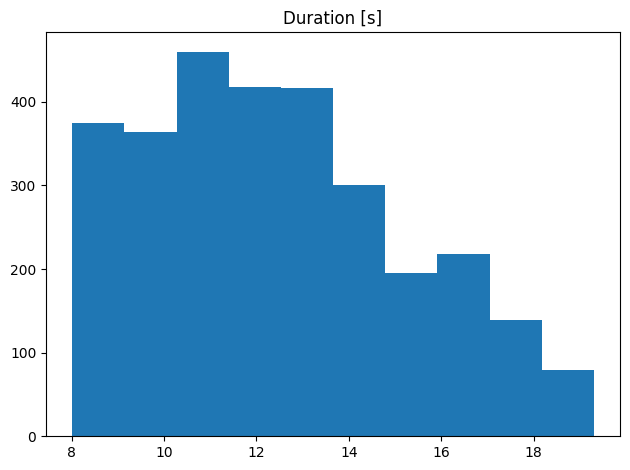

In [7]:
fig, axs = plt.subplots(1,1)
axs.hist(df['LEN']);
axs.set_title('Duration [s]')
fig.tight_layout()
plt.show()

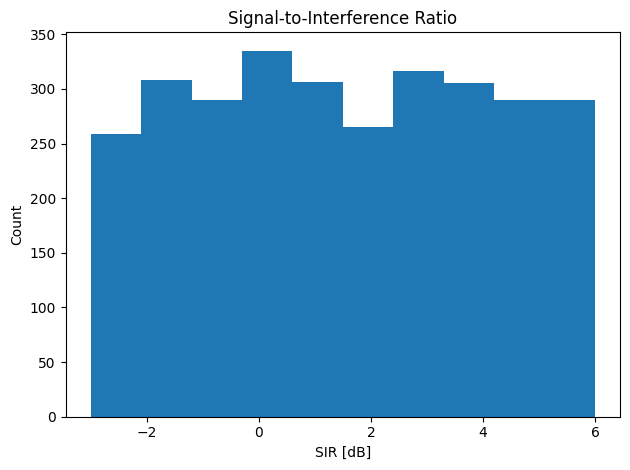

In [8]:
fig, axs = plt.subplots(1,1)
axs.hist(df['SIR']);
axs.set_xlabel('SIR [dB]')
axs.set_ylabel('Count')
axs.set_title('Signal-to-Interference Ratio')
fig.tight_layout()
plt.show()

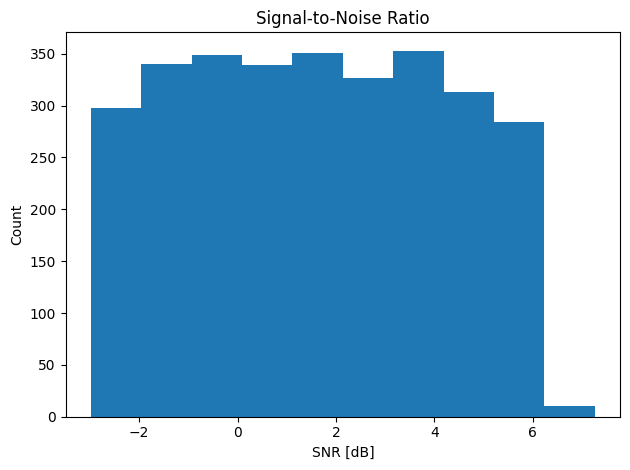

In [9]:
fig, axs = plt.subplots(1,1)
axs.hist(df['SNR']);
axs.set_xlabel('SNR [dB]')
axs.set_ylabel('Count')
axs.set_title('Signal-to-Noise Ratio')
fig.tight_layout()
plt.show()

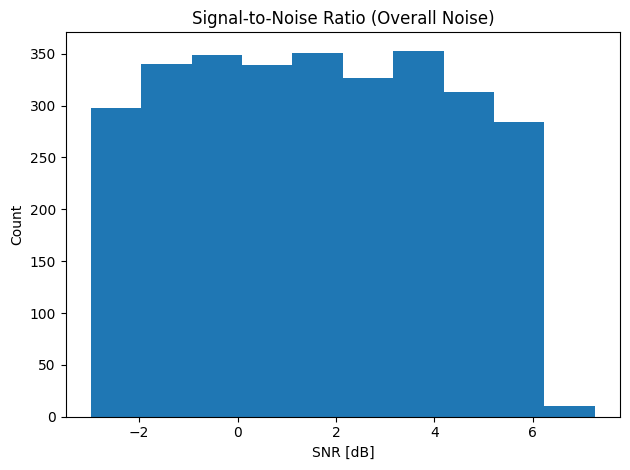

In [10]:
fig, axs = plt.subplots(1,1)
axs.hist(df['SNR']);
axs.set_xlabel('SNR [dB]')
axs.set_ylabel('Count')
axs.set_title('Signal-to-Noise Ratio (Overall Noise)')
fig.tight_layout()
plt.show()

___
# Plot Room

In [1]:
import matplotlib.pyplot as plt
import pyroomacoustics as pra
import sys
sys.path.append('/home/ovistetom/Documents/Python_Local/pyroom-database')
import src.roomacoustics.utils as utils

In [2]:
room_dim = utils.random_room_dimensions()
head_pos = utils.random_head_position(room_dim)
head_yaw = utils.random_head_yaw()
head_pitch = utils.random_head_pitch()
head_roll = utils.random_head_roll()
mics_pos = utils.random_mics_position(head_pos, head_yaw, head_pitch, head_roll)
mouth_pos = utils.random_mouth_position(head_pos, head_yaw, head_pitch, head_roll)
distr_pos = [utils.random_distractor_position(room_dim, head_pos) for _ in range(4)]
noise_pos = utils.random_noise_source_position(room_dim, head_pos, num_sources=48)
rt60 = utils.random_rt60(room_dim)
e_absorption, _ = pra.inverse_sabine(rt60, room_dim)
max_order = 10
sample_rate = 16000

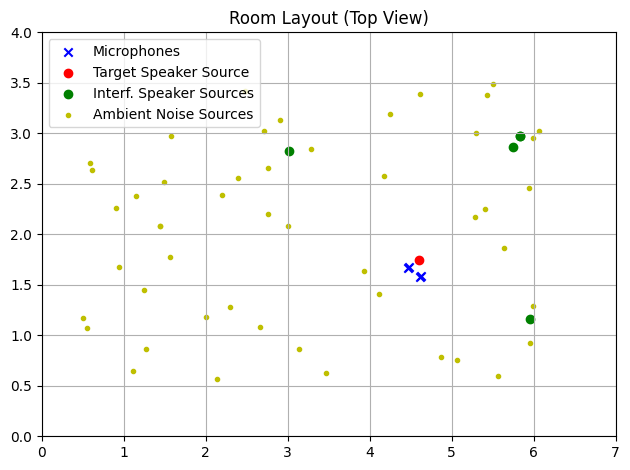

In [3]:
fig, axs = plt.subplots(1,1)
axs.scatter(mics_pos.T[0], mics_pos.T[1], c='b', marker='x', label='Microphones')
axs.scatter(mouth_pos[0], mouth_pos[1], c='r', marker='o', label='Target Speaker Source')
for distr_pos_i in distr_pos:
    axs.scatter(distr_pos_i[0], distr_pos_i[1], c='g', marker='o')
axs.scatter(distr_pos_i[0], distr_pos_i[1], c='g', marker='o', label='Interf. Speaker Sources')
for noise_pos_i in noise_pos:
    axs.scatter(noise_pos_i[0], noise_pos_i[1], c='y', marker='.')
axs.scatter(noise_pos_i[0], noise_pos_i[1], c='y', marker='.', label='Ambient Noise Sources')

axs.set_xlim(0, room_dim[0])
axs.set_ylim(0, room_dim[1])
axs.set_title('Room Layout (Top View)')
axs.grid()
axs.legend()
fig.tight_layout()
plt.savefig('/home/ovistetom/Documents/Python_Local/pyroom-database/fig/room_layout.png', bbox_inches='tight', dpi=300)
plt.show()